# 5. Evaluacija modela

### 5.1 Učitavanje biblioteka i modela

In [21]:
import numpy as np
import pandas as pd
import scipy.sparse
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Ucitavanje test podataka
X_test = scipy.sparse.load_npz('data/X_test.npz')
y_test = np.load('data/y_test.npy')

# Ucitavanje istreniranih modela
nb_grid = joblib.load('data/nb_model.joblib')
rf_grid = joblib.load('data/rf_model.joblib')

print(f'Test skup: {X_test.shape}')
print('Modeli ucitani.')

Test skup: (7697, 10000)
Modeli ucitani.


### 5.2 Najbolji parametri

In [22]:
print('NAJBOLJI PARAMETRI')
print(f'\nNaive Bayes:')
print(f'  alpha: {nb_grid.best_params_["alpha"]}')
print(f'  CV accuracy: {nb_grid.best_score_:.4f}')

print(f'\nRandom Forest:')
print(f'  Parametri: {rf_grid.best_params_}')
print(f'  CV accuracy: {rf_grid.best_score_:.4f}')

NAJBOLJI PARAMETRI

Naive Bayes:
  alpha: 0
  CV accuracy: 0.9805

Random Forest:
  Parametri: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  CV accuracy: 0.9977


### 5.3 Predikcija na test skupu

In [11]:
nb_best = nb_grid.best_estimator_
rf_best = rf_grid.best_estimator_

y_pred_nb = nb_best.predict(X_test)
y_pred_rf = rf_best.predict(X_test)

### 5.4 Evaluacija — Naive Bayes

NAIVE BAYES — EVALUACIJA

Accuracy:  0.9717

Classification Report:
              precision    recall  f1-score   support

   Lazne (0)       0.97      0.97      0.97      3459
Istinite (1)       0.98      0.97      0.97      4238

    accuracy                           0.97      7697
   macro avg       0.97      0.97      0.97      7697
weighted avg       0.97      0.97      0.97      7697



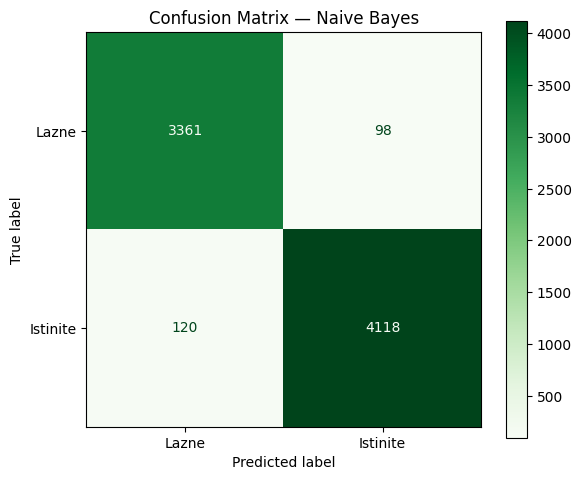

In [12]:
print('NAIVE BAYES — EVALUACIJA')
print(f'\nAccuracy:  {accuracy_score(y_test, y_pred_nb):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_nb, target_names=['Lazne (0)', 'Istinite (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nb,
    display_labels=['Lazne', 'Istinite'],
    cmap='Greens', ax=ax
)
ax.set_title('Confusion Matrix — Naive Bayes')
plt.tight_layout()
plt.show()

### 5.5 Evaluacija — Random Forest

RANDOM FOREST — EVALUACIJA

Accuracy:  0.9962

Classification Report:
              precision    recall  f1-score   support

   Lazne (0)       1.00      0.99      1.00      3459
Istinite (1)       0.99      1.00      1.00      4238

    accuracy                           1.00      7697
   macro avg       1.00      1.00      1.00      7697
weighted avg       1.00      1.00      1.00      7697



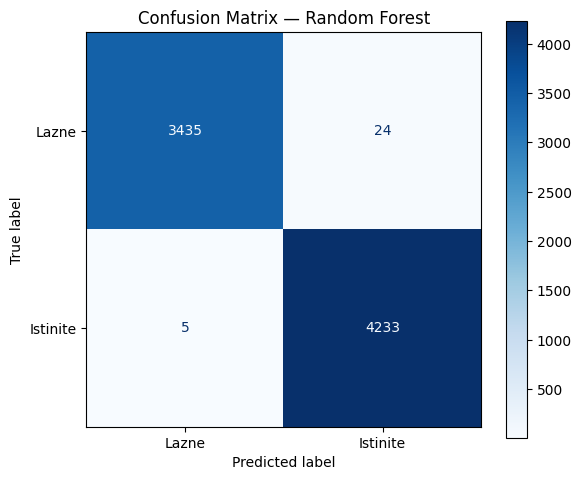

In [13]:
print('RANDOM FOREST — EVALUACIJA')
print(f'\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Lazne (0)', 'Istinite (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Lazne', 'Istinite'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

### 5.6 Poređenje modela

POREDJENJE MODELA
        Model  Accuracy  Precision   Recall  F1 Score
  Naive Bayes  0.971677   0.976755 0.971685  0.974213
Random Forest  0.996232   0.994362 0.998820  0.996586


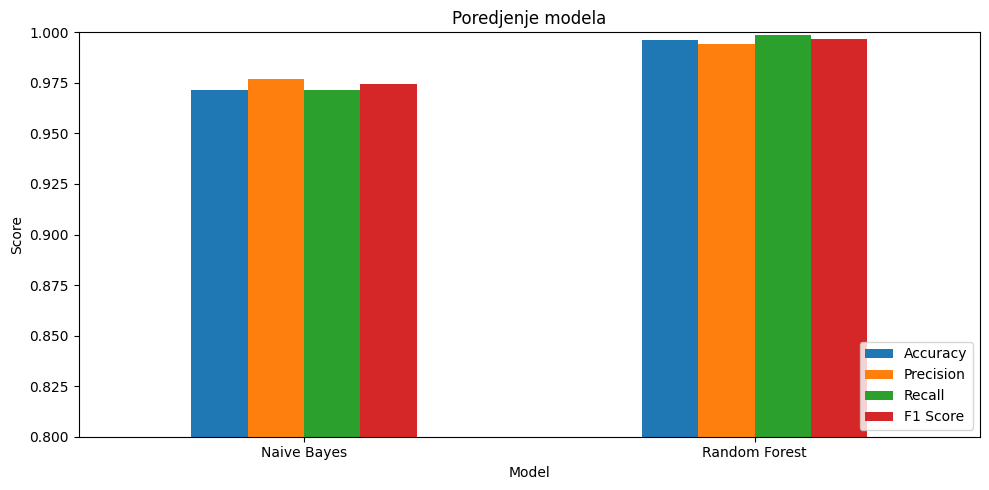

In [14]:
results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_nb), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_nb), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_nb), recall_score(y_test, y_pred_rf)],
    'F1 Score': [f1_score(y_test, y_pred_nb), f1_score(y_test, y_pred_rf)]
})

print('POREDJENJE MODELA')
print(results.to_string(index=False))

# Vizuelizacija
fig, ax = plt.subplots(figsize=(10, 5))
results.set_index('Model').plot(kind='bar', ax=ax, rot=0)
ax.set_ylim(0.8, 1.0)
ax.set_title('Poredjenje modela')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()